In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder


In [2]:
train_raw = pd.read_csv('3_normal_train.csv')
test_raw  = pd.read_csv('3_normal_test.csv')

print(train_raw.shape, test_raw.shape)


(26848, 10) (6712, 10)


In [3]:
station_pair_counts = train_raw.groupby(['startStation', 'endStation']).size().reset_index(name='count')
valid_pairs = station_pair_counts[station_pair_counts['count'] >= 10][['startStation', 'endStation']]

train_raw = train_raw.merge(valid_pairs, on=['startStation', 'endStation'], how='inner')
test_raw = test_raw.merge(valid_pairs, on=['startStation', 'endStation'], how='inner')

print(f"After filtering: train shape {train_raw.shape}, test shape {test_raw.shape}")
print(station_pair_counts)

After filtering: train shape (26790, 10), test shape (6700, 10)
    startStation  endStation  count
0              0           1   1454
1              0           2      7
2              1           2   1663
3              1           3      7
4              2           3   1850
5              2           4      9
6              3           4   1858
7              3           5     10
8              3           6      1
9              4           5   1813
10             4           6     26
11             4           7      3
12             5           6   1837
13             5           7      9
14             6           7   1863
15             6           8      8
16             7           8   1851
17             7           9     11
18             8           9   1846
19             8          10     12
20             9          10   1860
21             9          11     15
22             9          12      1
23            10          11   1556
24            10          12     11


In [4]:
def time_to_seconds(t):
    h, m, s = map(int, t.split(':'))
    return h * 3600 + m * 60 + s

for df in [train_raw, test_raw]:
    df['time_sec'] = df['time'].apply(time_to_seconds)
    df.sort_values('time_sec', inplace=True)
    df.reset_index(drop=True, inplace=True)


In [5]:
def add_lag_features(df):
    df = df.copy()

    lag_cols = ['weather', 'trafficCondition', 'passengerFlow']

    for col in lag_cols:
        df[f'{col}_lag1'] = df[col].shift(1)
        df[f'{col}_lag2'] = df[col].shift(2)
        df[f'{col}_roll3_mean'] = df[col].rolling(3).mean()

    df['arrivalDuration_lag1'] = df['arrivalDuration'].shift(1)
    df['arrivalDuration_roll3_mean'] = (
        df['arrivalDuration'].rolling(3).mean()
    )

    df.bfill(inplace=True)
    return df


train_df = add_lag_features(train_raw)
test_df  = add_lag_features(test_raw)


In [6]:
pair_te = (
    train_df
    .groupby(['startStation', 'endStation'])['arrivalDuration']
    .mean()
    .reset_index()
    .rename(columns={'arrivalDuration': 'pair_te_mean'})
)

train_df = train_df.merge(pair_te, on=['startStation', 'endStation'], how='left')
test_df  = test_df.merge(pair_te,  on=['startStation', 'endStation'], how='left')

global_mean = train_df['arrivalDuration'].mean()
train_df['pair_te_mean'] = train_df['pair_te_mean'].fillna(global_mean)
test_df['pair_te_mean']  = test_df['pair_te_mean'].fillna(global_mean)


In [7]:
SHORT_TH = 60

train_df['is_short'] = (train_df['arrivalDuration'] < SHORT_TH).astype(int)
test_df['is_short']  = (test_df['arrivalDuration'] < SHORT_TH).astype(int)

train_short = train_df[train_df['is_short'] == 1]
train_long  = train_df[train_df['is_short'] == 0]

test_short  = test_df[test_df['is_short'] == 1]
test_long   = test_df[test_df['is_short'] == 0]

print(len(train_short), len(train_long))


12735 14055


In [8]:
drop_cols = ['arrivalDuration', 'time', 'time_sec', 'busPlate']

def prepare_xy(df):
    X = df.drop(columns=drop_cols, errors='ignore')
    y_log = np.log1p(df['arrivalDuration'])
    return X, y_log


Xs_tr, ys_tr = prepare_xy(train_short)
Xl_tr, yl_tr = prepare_xy(train_long)

Xs_te, ys_te_raw = prepare_xy(test_short)
Xl_te, yl_te_raw = prepare_xy(test_long)


In [9]:
def build_dmatrix(X, y, raw_duration):
    weight = np.clip(raw_duration, 30, 300) / raw_duration.mean()
    return xgb.DMatrix(X, label=y, weight=weight)


ds_tr = build_dmatrix(Xs_tr, ys_tr, train_short['arrivalDuration'])
dl_tr = build_dmatrix(Xl_tr, yl_tr, train_long['arrivalDuration'])

ds_te = xgb.DMatrix(Xs_te)
dl_te = xgb.DMatrix(Xl_te)


In [10]:
params = {
    'objective': 'reg:squarederror',
    'max_depth': 4,
    'eta': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'gamma': 0.1,
    'reg_lambda': 2.0,
    'reg_alpha': 0.5,
    'seed': 42
}

model_short = xgb.train(params, ds_tr, num_boost_round=600)
model_long  = xgb.train(params, dl_tr, num_boost_round=600)


In [11]:
pred_short = np.expm1(model_short.predict(ds_te))
pred_long  = np.expm1(model_long.predict(dl_te))

test_df['predictedArrivalDuration'] = np.nan
test_df.loc[test_short.index, 'predictedArrivalDuration'] = pred_short
test_df.loc[test_long.index,  'predictedArrivalDuration'] = pred_long


In [12]:
y_true = test_df['arrivalDuration']
y_pred = test_df['predictedArrivalDuration']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

mask = y_true >= 60
mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

print("Final Dual-Model Results")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")


Final Dual-Model Results
MAE  : 15.23
RMSE : 22.65
MAPE : 21.46%


In [13]:
# eval_df = test_df.copy()
# eval_df['error'] = (
#     eval_df['predictedArrivalDuration']
#     - eval_df['arrivalDuration']
# )

# adjacent_df = eval_df[
#     (eval_df['endStation'] - eval_df['startStation']) == 1
# ]

# station_eval = (
#     adjacent_df
#     .groupby(['startStation', 'endStation'])
#     .agg(
#         Samples=('arrivalDuration', 'count'),
#         MAE=('error', lambda x: np.mean(np.abs(x))),
#         RMSE=('error', lambda x: np.sqrt(np.mean(x**2))),
#         MAPE=(
#             'arrivalDuration',
#             lambda x: np.mean(
#                 np.abs(
#                     (x - adjacent_df.loc[x.index, 'predictedArrivalDuration'])
#                     / np.maximum(x, 60)
#                 )
#             ) * 100
#         )
#     )
#     .reset_index()
# )

# station_eval

eval_df = test_df.copy()
eval_df['error'] = (
    eval_df['predictedArrivalDuration']
    - eval_df['arrivalDuration']
)

station_eval = (
    eval_df
    .groupby(['startStation', 'endStation'])
    .agg(
        Samples=('arrivalDuration', 'count'),
        MAE=('error', lambda x: np.mean(np.abs(x))),
        RMSE=('error', lambda x: np.sqrt(np.mean(x**2))),
        MAPE=(
            'arrivalDuration',
            lambda x: np.mean(
                np.abs(
                    (x - eval_df.loc[x.index, 'predictedArrivalDuration'])
                    / np.maximum(x, 60)
                )
            ) * 100
        )
    )
    .reset_index()
)

station_eval

,startStation,endStation,Samples,MAE,RMSE,MAPE
0,0,1,354,28.023448,37.352716,19.422928
1,1,2,422,23.258746,30.596449,15.597187
2,2,3,462,13.551266,19.972252,17.382168
3,3,4,468,16.886785,23.649222,19.713635
4,4,5,455,11.711667,16.413150,17.380450
5,4,6,5,21.454761,26.865892,15.455411
6,5,6,463,7.930270,10.799508,12.449529
7,6,7,461,20.031541,28.215902,19.133009
8,7,8,459,22.668017,31.198905,20.825412
9,7,9,1,31.728653,31.728653,11.973077


In [14]:
# station_eval.to_csv('xgb_normal-normal_remove.csv', index=False)
# print("Station-level evaluation saved")


In [15]:
test_df['mean_arrivalDuration'] = test_df['pair_te_mean']

test_df['error'] = test_df['predictedArrivalDuration'] - test_df['arrivalDuration']

detailed_cols = [
    'startStation', 'endStation', 'time', 'weekday',
    'passengerFlow', 'trafficCondition', 'busPlate',
    'passbyNum', 'weather', 'arrivalDuration',
    'predictedArrivalDuration', 'error', 'mean_arrivalDuration'
]

detailed_df = test_df[detailed_cols]

# detailed_df.to_csv('testset_predictions_detailed.csv', index=False)
# print("Detailed testset predictions saved: testset_predictions_detailed.csv")

detailed_df.head()


,startStation,endStation,time,weekday,passengerFlow,trafficCondition,busPlate,passbyNum,weather,arrivalDuration,predictedArrivalDuration,error,mean_arrivalDuration
0,9,10,0:00:00,6,-1,-1,MX1601,0,2,40,33.057327,-6.942673,38.537634
1,11,12,0:00:16,5,-1,-1,MX2239,0,1,50,30.150406,-19.849594,80.340996
2,4,5,0:00:16,5,-1,-1,AA7459,0,1,20,25.352190,5.352190,41.532819
3,0,1,0:00:26,5,-1,-1,MX1601,0,1,161,144.928543,-16.071457,143.165750
4,1,2,0:00:33,6,-1,-1,MW2614,0,2,133,131.594833,-1.405167,169.962117


In [16]:
external_file = "3_normal_train.csv"
external_df = pd.read_csv(external_file)

MIN_PAIR_SAMPLES = 5

ext_pair_counts = (
    external_df
    .groupby(['startStation', 'endStation'])
    .size()
    .reset_index(name='count')
)

ext_valid_pairs = ext_pair_counts[
    ext_pair_counts['count'] >= MIN_PAIR_SAMPLES
][['startStation', 'endStation']]

external_df_filtered = external_df.merge(
    ext_valid_pairs,
    on=['startStation', 'endStation'],
    how='inner'
)

external_pair_mean = (
    external_df_filtered
    .groupby(['startStation', 'endStation'])['arrivalDuration']
    .mean()
    .reset_index()
    .rename(columns={'arrivalDuration': 'external_pair_mean'})
)

test_df = test_df.merge(
    external_pair_mean,
    on=['startStation', 'endStation'],
    how='left'
)

global_mean = external_df['arrivalDuration'].mean()

test_df['external_pair_mean'] = (
    test_df['external_pair_mean']
    .fillna(global_mean)
)


p_values = np.linspace(0, 1, 100)
mape_list = []

y_true = test_df['arrivalDuration'].values

for p in p_values:
    fusion_pred = (
        p * test_df['predictedArrivalDuration'] +
        (1 - p) * test_df['external_pair_mean']
    )

    mask = y_true >= 60
    mape = np.mean(
        np.abs((y_true[mask] - fusion_pred[mask]) / y_true[mask])
    ) * 100

    mape_list.append(mape)

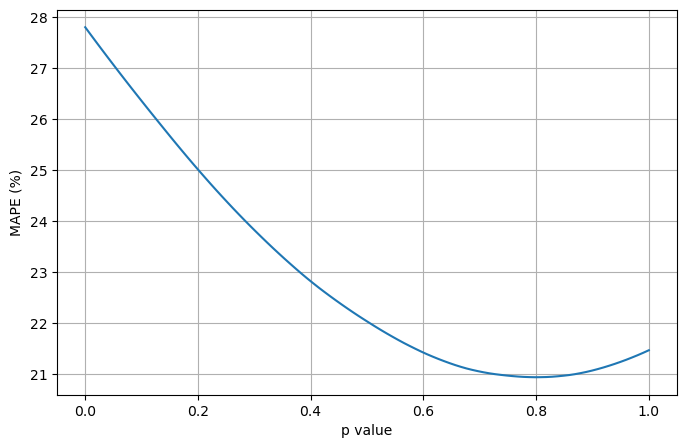

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(p_values, mape_list)

plt.xlabel('p value')
plt.ylabel('MAPE (%)')
# plt.title('MAPE vs Fusion Weight p')

plt.grid(True)
plt.savefig('Results/xgbmape.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
best_idx = np.argmin(mape_list)
best_p = p_values[best_idx]
best_mape = mape_list[best_idx]

print(f"Best p: {best_p:.4f}")
print(f"Best MAPE: {best_mape:.2f}%")

Best p: 0.7980
Best MAPE: 20.93%


In [19]:
# ==============================
# Nonlinear Fusion (Squared + sqrt)
# ==============================

fusion_pred_nonlinear = np.sqrt(
    (test_df['predictedArrivalDuration']**2 +
    test_df['external_pair_mean']**2)/2
)

mask = y_true >= 60
mape_nonlinear = np.mean(
    np.abs((y_true[mask] - fusion_pred_nonlinear[mask]) / y_true[mask])
) * 100

print("\nNonlinear Fusion (Squared) Results:")
print(f"MAPE: {mape_nonlinear:.2f}%")


Nonlinear Fusion (Squared) Results:
MAPE: 21.94%


In [20]:
# ==============================
# Simple Average Fusion
# ==============================

fusion_pred_avg = (
    test_df['predictedArrivalDuration'] +
    test_df['external_pair_mean']
) / 2

mask = y_true >= 60
mape_avg = np.mean(
    np.abs((y_true[mask] - fusion_pred_avg[mask]) / y_true[mask])
) * 100

print("\nSimple Average Fusion Results:")
print(f"MAPE: {mape_avg:.2f}%")


Simple Average Fusion Results:
MAPE: 22.03%


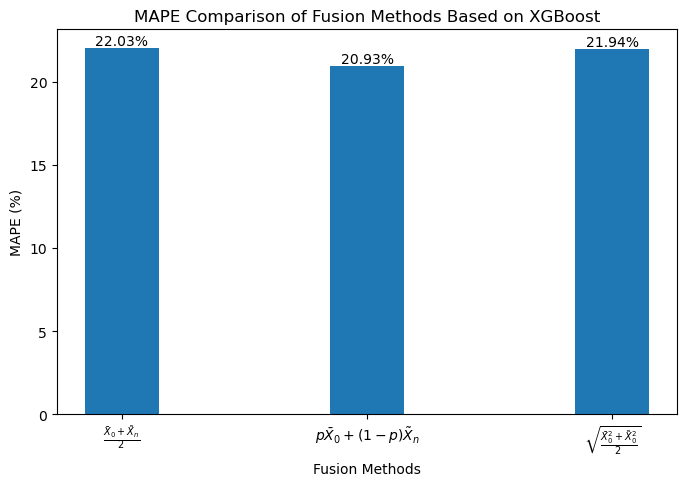

In [21]:
# ==============================
# Bar Chart: Fusion Method Comparison
# ==============================

import matplotlib.pyplot as plt

methods = [
    r'$\frac{\bar{X}_0 + \tilde{X}_n}{2}$',
    r'$p\bar{X}_0 + (1-p)\tilde{X}_n$',
    r'$\sqrt{\frac{\bar{X}_0^2+\tilde{X}_0^2}{2}}$'
]
mape_values = [mape_avg, best_mape, mape_nonlinear]

plt.figure(figsize=(8, 5))
plt.bar(methods, mape_values, width=0.3)

plt.ylabel('MAPE (%)')
plt.xlabel('Fusion Methods')
plt.title('MAPE Comparison of Fusion Methods Based on XGBoost')

for i, v in enumerate(mape_values):
    plt.text(i, v, f"{v:.2f}%", ha='center', va='bottom')

plt.grid(False)

plt.savefig('Results/xgb_fusion_method_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()